In [1]:
import sys
!{sys.executable} --version

import math
import numpy as np
from datetime import datetime
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline

from scipy.optimize import minimize
from math import log

Python 3.11.5


# get price histories

In [2]:
# https://en.wikipedia.org/wiki/Dow_Jones_Industrial_Average

companies, tickers = ['Honeywell','Salesforce'],['HON','CRM']

tickers_df = yf.download(tickers, 
                      start='2017-01-01', 
                      end='2025-02-03', 
                      progress=False, auto_adjust=True)
display(tickers_df.head())
display(tickers_df.tail())

returns = tickers_df['Close'].applymap(log).diff()[1:]

stats = returns.agg(['mean', 'std', 'var'])

Price           Close                  High                   Low             \
Ticker            CRM        HON        CRM        HON        CRM        HON   
Date                                                                           
2017-01-03  69.693207  87.146553  70.009365  87.686622  68.171693  86.681492   
2017-01-04  71.926071  87.386620  72.192827  87.739163  69.910560  87.034070   
2017-01-05  71.916199  87.581657  72.775758  88.106725  71.659318  87.176602   
2017-01-06  72.914070  88.909317  73.240103  89.044338  71.679076  87.394119   
2017-01-09  73.072166  88.174240  73.546408  88.804326  72.627571  88.174240   

Price            Open              Volume           
Ticker            CRM        HON      CRM      HON  
Date                                                
2017-01-03  68.458212  87.484095  8112200  3348443  
2017-01-04  70.226718  87.491631  9289500  3256341  
2017-01-05  71.935955  87.409133  4695600  2934758  
2017-01-06  72.014991  87.716660  4466100  4000353  
2017-01-09  73.161090  88.714310  3933100  4276438

Price            Close                    High                     Low  \
Ticker             CRM         HON         CRM         HON         CRM   
Date                                                                     
2025-01-27  344.848724  208.187958  350.859472  208.335538  328.356385   
2025-01-28  357.615356  203.566864  364.709030  207.274789  348.186888   
2025-01-29  351.703949  203.889709  357.843858  205.503852  349.220164   
2025-01-30  341.341614  206.666031  345.742874  207.256353  337.794761   
2025-01-31  339.483704  206.352432  347.233100  208.409316  337.894075   

Price                         Open                Volume           
Ticker             HON         CRM         HON       CRM      HON  
Date                                                               
2025-01-27  203.013456  330.204307  203.151823  15661100  3300347  
2025-01-28  203.078010  352.468931  207.274789  12099300  3818751  
2025-01-29  203.520766  356.433085  203.797470   6266700  2033194  
2025-01-30  204.378555  338.688918  204.812068   7591100  1924017  
2025-01-31  205.273256  345.742829  205.549975   5778000  2632978

# get the EWMA volatility estimates
## and the percentage of days that are exceptions

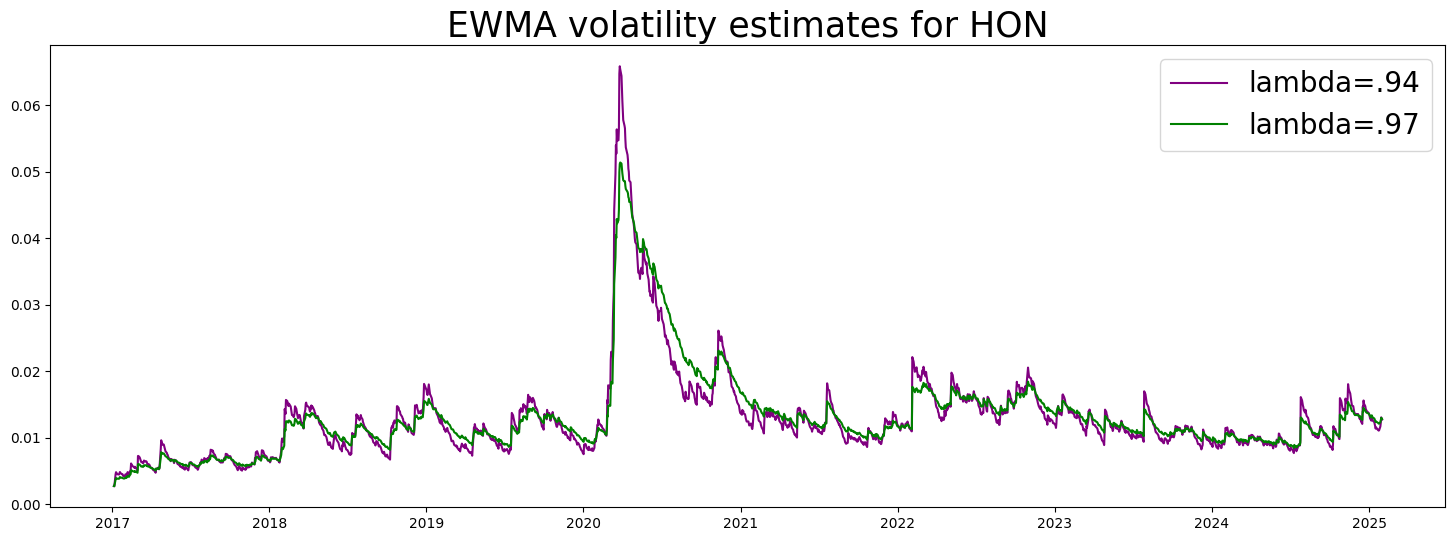

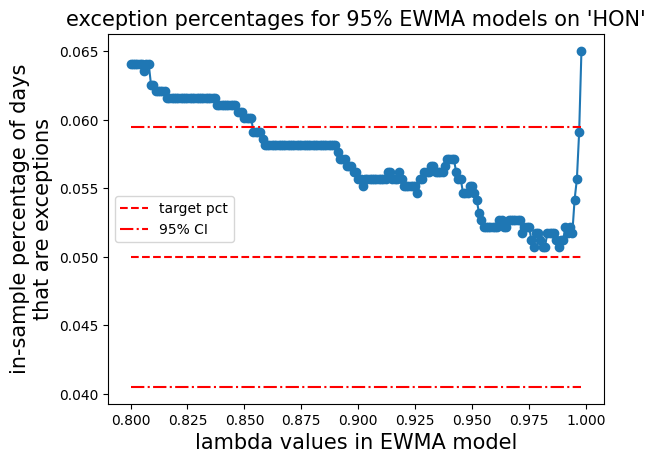

In [3]:
def rolling_vol(lambda0, r):
    """ calculate rolling EWMA volatilities """
    sigma = []
    sigma2 = r[0] * r[0]
    for r0 in r:
        sigma2 = lambda0 * sigma2 + (1 - lambda0) * r0 * r0
        sigma.append(np.sqrt(sigma2))
    sigma = pd.DataFrame(sigma[:-1], index = r.index[1:])
    return sigma

def exception_counter(lambda0, r, stds=-1.645):
    """ count the number of exceptions for EWMA with a specified lamda (wt) """
    sigma = rolling_vol(lambda0, r)
    exceptions = sum([1 for s0, r0 in zip(sigma.iloc[:,0], r[1:]) if r0 < stds * s0])
    return {"exceptions":exceptions, "days":len(r) - 1, "exception_pct":exceptions/(len(r) - 1)}

ticker = tickers[0]
r = returns[ticker]
v94 = rolling_vol(.94, r)
v97 = rolling_vol(.97, r)

lambda_fits = pd.DataFrame([(lambda0, exception_counter(lambda0, r)["exceptions"], len(r)-1) 
     for lambda0 in np.arange(.800,.999,.001)], columns=['lambda','exceptions','days'])

confidence_interval_95 = 1.96 *  np.sqrt(.05 * .95 / (len(r) - 1))

plt.figure(figsize=(18,6))
plt.plot(v94, color='purple', label='lambda=.94')
plt.plot(v97, color='green', label='lambda=.97')
plt.title(f"EWMA volatility estimates for {ticker}",fontsize=25)
plt.legend(fontsize=20)
plt.show()

lambda_fits['percentages'] = lambda_fits['exceptions'] /  lambda_fits['days']
plt.plot(lambda_fits['lambda'], lambda_fits['percentages'], 'o-')
plt.plot(lambda_fits['lambda'], [.05] * len(lambda_fits), '--', color='red', label='target pct')
plt.plot(lambda_fits['lambda'], [.05 + confidence_interval_95] * len(lambda_fits), '-.', color='red', label='95% CI')
plt.plot(lambda_fits['lambda'], [.05 - confidence_interval_95] * len(lambda_fits), '-.', color='red')
plt.legend()
plt.title(f"exception percentages for 95% EWMA models on '{ticker}'",fontsize=15)
plt.xlabel("lambda values in EWMA model",fontsize=15)
plt.ylabel("in-sample percentage of days\nthat are exceptions",fontsize=15)
plt.show()


## use an optimizer to calculate the best fit values of lambda

In [4]:
def count_pct(wt):
    ec = exception_counter(wt, r)
    search_history.append((wt, ec["exception_pct"], pow(ec["exception_pct"] - .05, 2)))
    return pow(ec["exception_pct"] - .05, 2)

search_history = []
X0 = .80
res1 = minimize(count_pct, X0, method='Powell', tol= 1e-10)  # minimize the squared deviation from 5%
print(res1)
print()
xx = res1['x']

print(f"'{ticker}': best fit value of lambda = {xx[0]:0.4f}\n")
print(f"exceptions = {exception_counter(xx, r)}")

C:\Users\ellio\AppData\Local\Temp\ipykernel_127896\817662395.py:7: RuntimeWarning: invalid value encountered in sqrt
  sigma.append(np.sqrt(sigma2))
C:\Users\ellio\AppData\Local\Temp\ipykernel_127896\817662395.py:6: RuntimeWarning: overflow encountered in multiply
  sigma2 = lambda0 * sigma2 + (1 - lambda0) * r0 * r0


 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 5.459972336140171e-07
       x: [ 9.816e-01]
     nit: 3
   direc: [[ 1.000e+00]]
    nfev: 137

'HON': best fit value of lambda = 0.9816

exceptions = {'exceptions': 103, 'days': 2030, 'exception_pct': 0.05073891625615764}


# plot search history of the optimizer

,weight,exceptions,fit
0,[0.8],0.064039,0.000197
1,[0.8],0.064039,0.000197
2,[1.8],0.000000,0.002500
3,[-0.8180339999999999],0.026108,0.000571


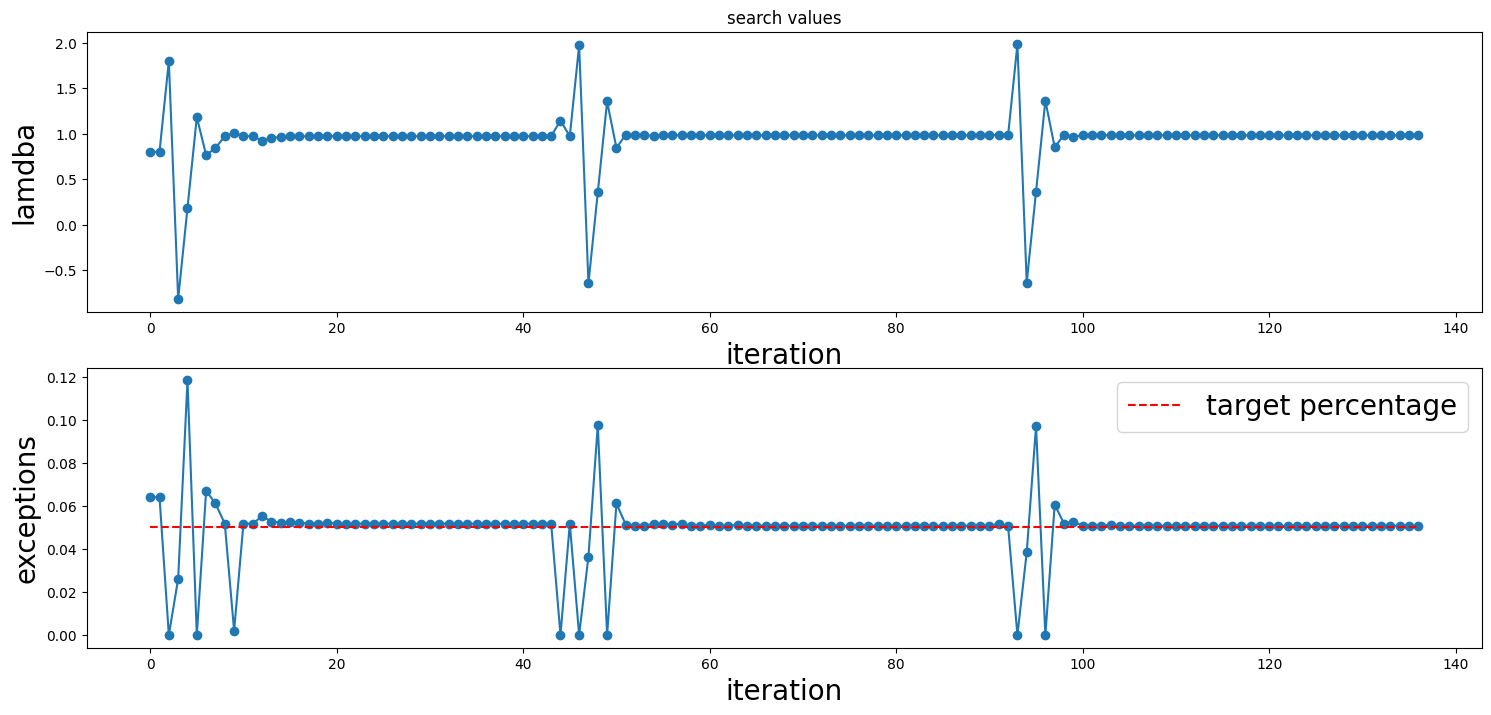

In [5]:
search_history_df = pd.DataFrame(search_history, columns=['weight','exceptions','fit'])
display(search_history_df[:4])

f, (ax1, ax2) = plt.subplots(2,1,figsize=(18,8))

ax1.plot(search_history_df['weight'],'o-')
ax1.set_title('search values')
ax1.set_ylabel('lamdba', fontsize=20)
ax1.set_xlabel('iteration', fontsize=20)

ax2.plot(search_history_df['exceptions'],'o-')
ax2.set_ylabel('exceptions', fontsize=20)
ax2.set_xlabel('iteration', fontsize=20)
ax2.plot([0.05] * len(search_history_df['exceptions']), '--', color='red', label='target percentage')
ax2.legend(fontsize=20)

plt.show()

# plot search space

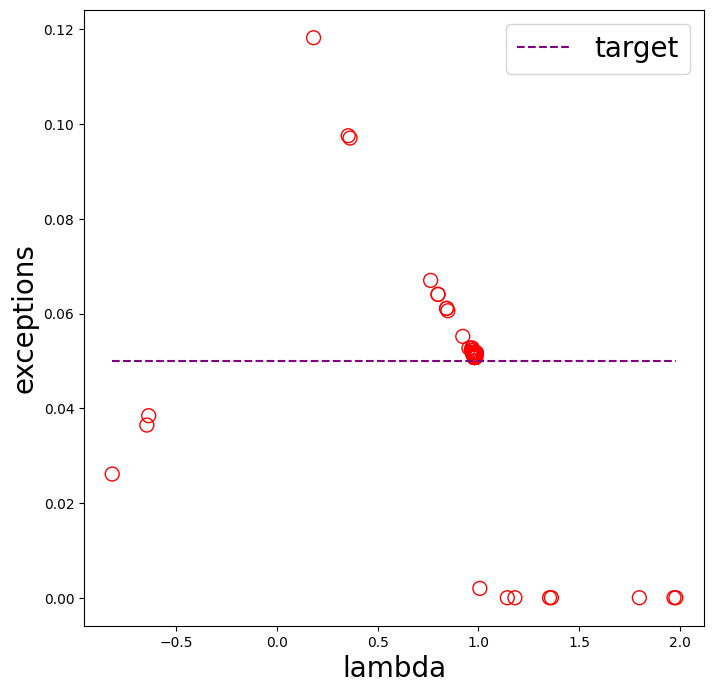

In [6]:
plt.figure(figsize=(8,8))
xs = plt.scatter(search_history_df['weight'], search_history_df['exceptions'],s=100,facecolors='none', edgecolors='r')
plt.plot([min(search_history_df['weight']), max(search_history_df['weight'])],[0.05] * 2,  '--', color='purple', label='target')
plt.xlabel('lambda',fontsize=20)
plt.ylabel('exceptions',fontsize=20)
plt.legend(fontsize=20)
plt.show()